In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv("mushrooms.csv")

In [3]:
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
data.shape

(8124, 23)

In [5]:
data.dtypes

class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [7]:
data.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [8]:
data["class"].unique()

array(['p', 'e'], dtype=object)

<Axes: xlabel='class', ylabel='Count'>

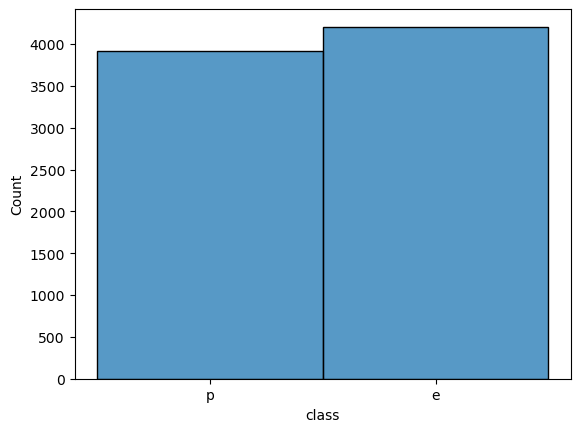

In [9]:
sns.histplot(data["class"])

In [10]:
x=data.drop(["class"],axis=1)
y=data["class"]

In [11]:
x.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [12]:
x=pd.get_dummies(x)
x.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [13]:
x.shape

(8124, 117)

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y=encoder.fit_transform(y)
print(y)

[1 0 0 ... 0 1 0]


In [15]:
from sklearn.model_selection import train_test_split
x_train ,x_test,y_train,y_test=train_test_split(x,y,train_size=0.33,random_state=42)

In [16]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="gini" ,max_depth=3,random_state=0)

In [17]:
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [18]:
pred=model.predict(x_test)

In [19]:
pred

array([0, 1, 1, ..., 1, 0, 1])

In [20]:
from sklearn.metrics import  accuracy_score 
accuracy_score(y_test,pred)

0.9849375459221161

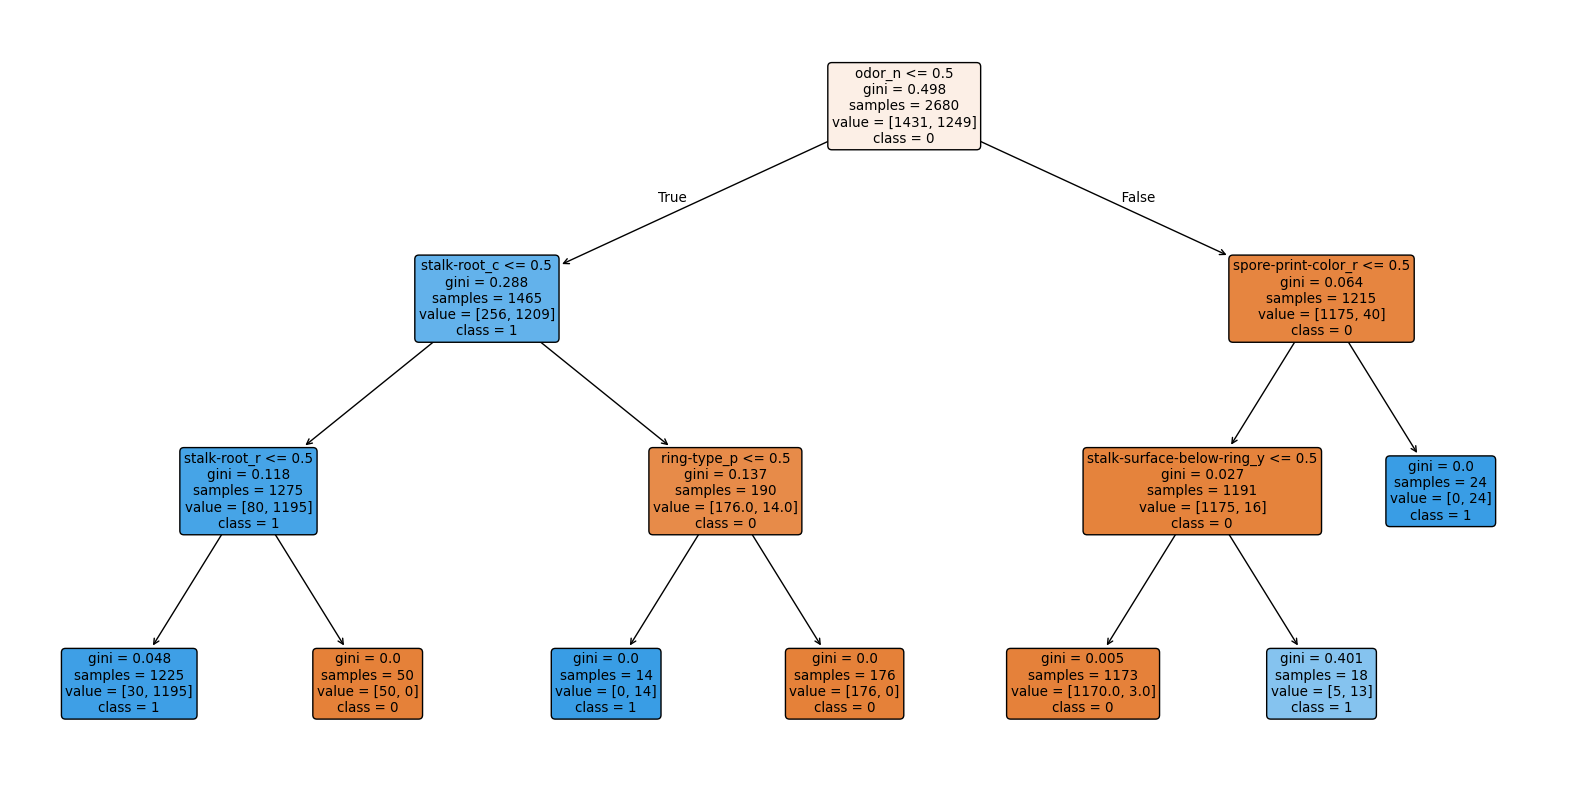

In [21]:

from sklearn import tree


# Plot tree
plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    feature_names=x_train.columns,
    class_names=[str(i) for i in model.classes_],
    filled=True,
    rounded=True
)

plt.show()

In [22]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy" ,max_depth=3,random_state=0)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

[Text(0.5555555555555556, 0.875, 'x[27] <= 0.5\nentropy = 0.997\nsamples = 2680\nvalue = [1431, 1249]'),
 Text(0.3333333333333333, 0.625, 'x[20] <= 0.5\nentropy = 0.668\nsamples = 1465\nvalue = [256, 1209]'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'x[53] <= 0.5\nentropy = 0.974\nsamples = 431\nvalue = [256, 175]'),
 Text(0.1111111111111111, 0.125, 'entropy = 0.897\nsamples = 255\nvalue = [80, 175]'),
 Text(0.3333333333333333, 0.125, 'entropy = 0.0\nsamples = 176\nvalue = [176, 0]'),
 Text(0.4444444444444444, 0.375, 'entropy = 0.0\nsamples = 1034\nvalue = [0, 1034]'),
 Text(0.7777777777777778, 0.625, 'x[100] <= 0.5\nentropy = 0.209\nsamples = 1215\nvalue = [1175, 40]'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'x[63] <= 0.5\nentropy = 0.103\nsamples = 1191\nvalue = [1175, 16]'),
 Text(0.5555555555555556, 0.125, 'entropy = 0.026\nsamples = 1173\nvalue = [1170.0, 3.0]'),
 Text(0.7777777777777778, 0.125, 'entropy = 0.

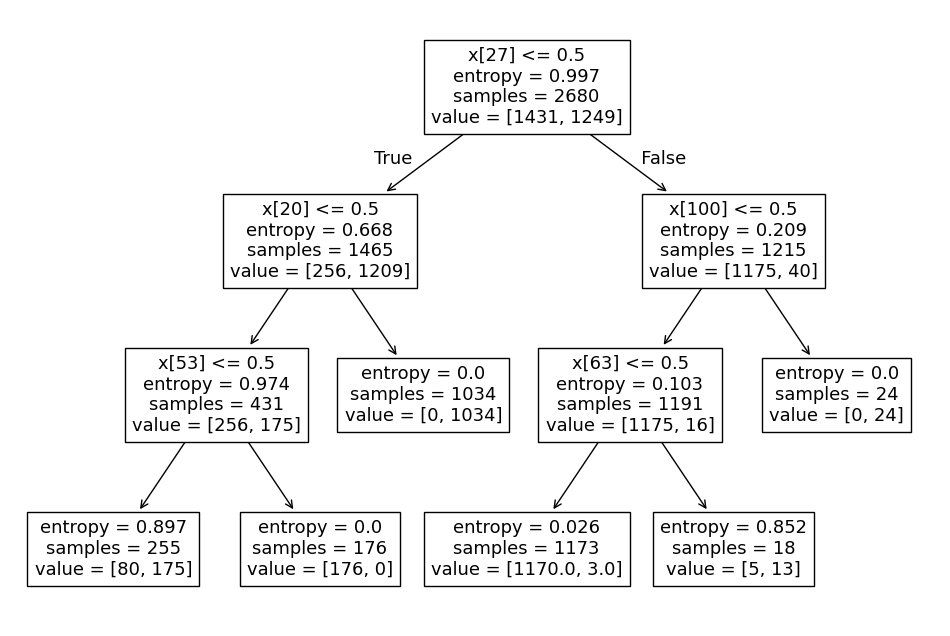

In [23]:
plt.figure(figsize=(12,8))
tree.plot_tree(model)


In [24]:
y_pred=model.predict(x_test)
y_pred

array([0, 1, 1, ..., 1, 0, 1])

In [25]:
train=model.predict(x_train)

In [26]:
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))

0.9671641791044776
0.9588537839823659


In [27]:
accuracy_score(y_test,y_pred)

0.9588537839823659

In [28]:
accuracy_score(y_train,train)

0.9671641791044776

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

cm=confusion_matrix(y_test,y_pred)
cm

array([[2558,  219],
       [   5, 2662]])

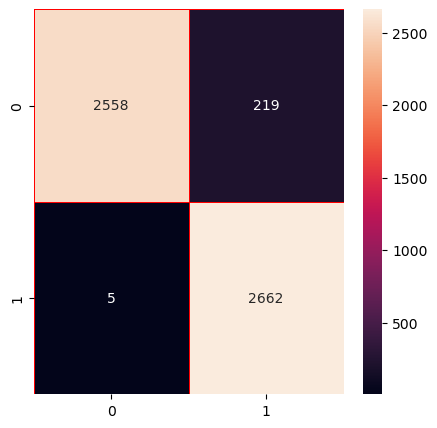

In [30]:
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.savefig("Confusion.png")
plt.show()

In [33]:

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2777
           1       0.92      1.00      0.96      2667

    accuracy                           0.96      5444
   macro avg       0.96      0.96      0.96      5444
weighted avg       0.96      0.96      0.96      5444

